# Μετάπτωση του Spin

## Μετάπτωση Larmor

Σ αυτό το notebook θα δουμε τι συμβάνει στο spin του ηλεκτρονίου όταν εκτίθεται σε ένα ομοιογενές σταθερό μαγνητικό πεδίο. Πως εφαρμόζουμε αλλαγή βάσης, πως χειριζόμαστε ορθοκανονικές καταστάσεις και διαγωνιοποιούμε τις Χαμιλτονιανές.

Η Χαμιλτονιανή σε ένα μαγνητικό δίπολο σε ομοιογενές μαγνητικό πεδίο δίνεται από τη σχέση:
$$H=-\vec{\mu}\cdot \vec{B}$$
Το μαγνητικό δίπολο του ηλεκτρονίου δίνεται από τη σχέση:
$$ \vec{\mu} = \gamma \vec{S}$$
Οπου  $\gamma$ είναι ο γυρομαγνητικός λόγος του ηλεκτρονίου. Η ακριβής τιμή του $\gamma$ υπολογίζεται από την κβαντική θεωρία πεδίου και δίνεται κατά προσέγγιση από τη σχέση:
$$\gamma \approx 2\left( 1 + \frac{\alpha}{2\pi}\right)$$
όπου $\alpha$ είναι η σταθερά λεπτής υφής, $\alpha \approx 1/137$.  Το διάνυσμα του σπιν δίνεται από τους πίνακες Pauli,

$$ \vec{S} = \frac{\hbar}{2}\vec{\sigma}$$
Επομένως η Χαμιλτονιανή για το spin του ηλεκτρονίου σε μαγνητικό πεδίο είναι:
$$ H = -\gamma \frac{\hbar}{2}\sum_i \sigma_i B_i$$
όπου $i=x,y,z$.

Σ αυτό το notebook, υποθέτουμε ότι $\hbar=1$ and $|B|=3T$.

### Αναφορές

Larmor Precession, Griffiths, Chapter 4, page 178

Changing Bases, Griffiths, Appendix A.4

Pauli matrices, https://en.wikipedia.org/wiki/Pauli_matrices

Scipy "eigh" function, https://docs.scipy.org/doc/numpy/reference/generated/numpy.linalg.eigh.html#numpy.linalg.eigh





### Προγραμματίζοντας τη Χαμιλτονιανή
Φορτώνουμε της βιβλιοθήκες και θέτουμε $ | B | = 3Τ $.

In [20]:
%matplotlib ipympl
import matplotlib
import matplotlib.pyplot as plt 
from matplotlib.widgets import Slider, Button, RadioButtons
import numpy
import numpy.linalg
import math

In [21]:
B=3    #  
alpha = 1./137   # Σταθερά λεπτής υφής
g = 2*(1+alpha/(2*numpy.pi)) # γυρομαγνητικός λόγος
hbar = 1   # Η σταθερά του Planck

#### Ερώτηση 1
Ας υποθέσουμε ότι το διάνυσμα του μαγνητικού πεδίου βρίσκεται στο επίπεδο Y-Z και ότι σχηματίζει γωνία $\theta$ με τον άξονα z.  Συμπληρώστε αυτές τις τρεις συναρτήσεις για να επιστρέψετε τους πίνακες Pauli, το διάνυσμα μαγνητικού πεδίου και τη Χαμιλτονιανή. Για να ελέγξετε την εργασία σας, βεβαιωθείτε ότι η Χαμιλτονιανή που υπολογίζεται για $ |B| = 3Τ $ και $\theta = \pi/4 $ είναι σωστή.

In [22]:
def pauli_matrices():
    sig_x = numpy.matrix([[0, 1], [1, 0]])
    sig_y = numpy.matrix([[0, -1j], [1j, 0]])
    sig_z = numpy.matrix([[1, 0], [0, -1]])
    
    sigmas = numpy.array([sig_x, sig_y, sig_z])
    return sigmas

def magnetic_field(theta, B):
    return numpy.array([0, B * numpy.sin(theta), B * numpy.cos(theta)]) 

def Hamiltonian(theta, B):
    sigmas = pauli_matrices()
    B_vector = magnetic_field(theta, B)
    
    dot_product = numpy.tensordot(B_vector, sigmas, axes=1)
    H = -g * (hbar / 2) * dot_product
    return H

theta_check = numpy.pi / 4
print("H=\n", Hamiltonian(theta_check, B))

H=
 [[-2.12378471+0.j          0.        +2.12378471j]
 [-0.        -2.12378471j  2.12378471-0.j        ]]


## Διαγωνιοποίηση της Hamiltonian
Οι πίνακες Pauli είναι συνήθως ως προς τη βάση $S_Z$, οπότε η παραπάνω Χαμιλτονιανή δεν θα είναι διαγώνια εάν το μαγνητικό πεδίο δεν είναι κατά μήκος του άξονα z. Προκειμένου να βρούμε τις ιδιοενέργειες και τις ιδιοκαταστάσεις για το ηλεκτρόνιο στο μαγνητικό πεδίο, μπορούμε να χρησιμοποιήσουμε την ["eigh" συνάρτηση της Scipy](https://docs.scipy.org/doc/numpy/reference/generated/numpy.linalg.eigh.html#numpy.linalg.eigh).
#### Ερώτηση 2
Χρησιμοποιήστε την "eigh" για να βρείτε τις ενέργειες και τις ιδιοκαταστάσεις για $\theta = \pi/3 $ και $ | Β | = 3Τ $.  Οι ιδιοσυναρτήσεις επιστρέφονται σε ένα πίνακα, $\Psi $, όπου κάθε στήλη είναι μια ιδιοκατάσταση. Οι ιδιοσυναρτήσεις πρέπει να είναι ορθογώνιες, έτσι ώστε $ \Psi^\dagger \Psi = Ι $.  Ελέγξτε ότι αυτό ισχύει.

In [23]:
H = Hamiltonian(numpy.pi/3, B)
print("H=\n", H)

# 1. Εύρεση ενεργειών και ιδιοκαταστάσεων
(energies, eigenstates) = numpy.linalg.eigh(H)
print("E=", energies)
print("Psi=\n", eigenstates)

# 2. Υπολογισμός του γινομένου Psi^dagger * Psi
# Το Psi^dagger είναι το eigenstates.conj().T
identity_check = numpy.dot(eigenstates.conj().T, eigenstates)

# Χρησιμοποιώ numpy.round() για να στρογγυλοποιήσω πολύ μικρά δεκαδικά σφάλματα της Python
print("Psi.conj.T * Psi =\n", numpy.round(identity_check, 5))

H=
 [[-1.50174257+0.j          0.        +2.60109444j]
 [-0.        -2.60109444j  1.50174257-0.j        ]]
E= [-3.00348514  3.00348514]
Psi=
 [[-0.8660254-0.j        -0.5      +0.j       ]
 [ 0.       -0.5j        0.       +0.8660254j]]
Psi.conj.T * Psi =
 [[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]


Κάθε ιδιοκατάσταση υπακούει στην χρονικά ανεξάρτητη εξίσωση Schrodinger.
$$ Η \psi_i = Ε_i \psi_i $$
Σε αυτή την εξίσωση η $Ε$ είναι μια βαθμωτή τιμή.  Θα μπορούσαμε να γράψουμε αυτήν την εξίσωση για κάθε ιδιοκατάσταση, αλλά υπάρχει ένας πιο ωραίος τρόπος για να την εκφράσουμε σαν μια εξίσωση πινάκων.
$$ Η \psi = \psi Ε $$
Όπου τώρα $Ε$ είναι ένας διαγώνιος πίνακας όπου ένα στοιχείο $ Ε (i, i) $ είναι η ενέργεια της $i$ ιδιοκατάστασης. Πάνω, δείξαμε ότι $ \Psi^\dagger \Psi = Ι $, που σημαίνει ότι $ \Psi^\dagger = \Psi^{-1}$.  Επομένως
$$\Psi^{-1}H\Psi = \Psi^{\dagger}H\Psi = E$$
Έτσι ο $\Psi$ είναι ο πίνακας μετασχηματισμού της Hamiltonian!
#### Ερώτηση 3
Ελέγξτε  ότι $\psi^{\dagger} Η \psi = Ε$ μας δίνει διαγώνιο πίνακα.

In [24]:
print() # Εκτυπώστε το διαγώνιο πίνακα

## Χρόνος εξέλιξης των πιθανοτήτων
Ας υποθέσουμε ότι στο $ t = 0 $, το ηλεκτρόνιο μετράται  να έχει $ s_z = \hbar/2 $, έτσι ώστε η κατάσταση να είναι $ \chi (0) = | \uparrow>_z $. Στη βάση  z
$$\chi(0)_z = \left( \begin{array}{ccc}
1 \\
0  \end{array} \right)_z=1*|\uparrow>_z+0*|\downarrow>_z$$

Ωστόσο, θα μπορούσαμε επίσης να γράψουμε τις καταστάσεις στη βάση των ιδιοδιανυσμάτων, όπου η κατάσταση spin-up σημαίνει ότο το spin προσανατολίζεται κατά μήκος της κατεύθυνσης του μαγνητικού πεδίου, όπου
$$\chi(0)_B = \left( \begin{array}{ccc}
a \\
b  \end{array} \right)_B =a*|\uparrow>_B+b*|\downarrow>_B$$
and $a^2+b^2=1$.  


Πώς πηγαίνουμε από τη μια βάση στο άλλη;  Μετατρέπουμε  την κατάσταση με τον ίδιο πίνακα μετασχηματισμού που χρησιμοποιήσαμε για τη Hamiltonian, το πίνακα των ιδιοδιανυσμάτων.
$$ \chi(0)_B = \Psi^\dagger \chi(0)_z$$

#### Ερώτηση 4
Δεδομένου ότι $\chi(0)=|\uparrow>_z$, ποια ειναι η $ \chi (0) $ στη βάση Β αν $ \theta = \pi/5 $;


In [25]:
H = Hamiltonian(numpy.pi/5, B)
(energies, eigenstates) = numpy.linalg.eigh(H)
psi_0_zbasis = numpy.matrix([[1],[0]])
psi_0_Bbasis = numpy.dot(eigenstates.conj().T, psi_0_zbasis) #ποια είναι η \chi(0)_B?
print("chi(0)_z=\n",psi_0_zbasis)
print("chi(0)_B=\n",psi_0_Bbasis)

chi(0)_z=
 [[1]
 [0]]
chi(0)_B=
 [[-0.95105652+0.j]
 [-0.30901699+0.j]]


Τώρα που έχουμε την αρχική κατάσταση στη βάση Β, τη βάση των ιδιοκαταστάσεων, μπορούμε εύκολα να βρούμε την εξέλιξη της κατάστασης.
$$\chi(t)_B = \left( \begin{array}{ccc}
a*e^{-iE_\uparrow t/\hbar} \\
b*e^{-iE_\downarrow t/\hbar}  \end{array} \right)_B =a*e^{-iE_\uparrow t/\hbar}|\uparrow>_B+b*e^{-iE_\downarrow t/\hbar}|\downarrow>_B$$
και $a^2+b^2=1$.  

#### Ερώτηση 5
Γράψτε μια συνάρτηση για να υπολογίσετε το $\chi (t)_b $ από το $\chi(0)_B$, τις ιδιοενέργειες και το χρόνο.  Εκτυπώστε το $\chi(t = 5)_B$ για $\theta = \pi/3 $.

In [26]:
H = Hamiltonian(numpy.pi/3, B) 
(energies, eigenstates) = numpy.linalg.eigh(H)
psi_0_zbasis = numpy.matrix([[1],[0]])
psi_0_Bbasis = numpy.dot(eigenstates.conj().T, psi_0_zbasis)

def get_psi_t_Bbasis(energies, psi_0_Bbasis, time):
    psi_t_Bbasis = numpy.matrix(numpy.zeros_like(psi_0_Bbasis))
    for i in range(0, len(energies)):
        # Υπολογισμός χρονικής εξέλιξης: c_i(t) = c_i(0) * exp(-i*E_i*t)
        psi_t_Bbasis[i,0] = psi_0_Bbasis[i,0] * numpy.exp(-1j * energies[i] * time)
    return psi_t_Bbasis

print(H)
print("chi(t=5)_B=\n", get_psi_t_Bbasis(energies, psi_0_Bbasis, 5))

[[-1.50174257+0.j          0.        +2.60109444j]
 [-0.        -2.60109444j  1.50174257-0.j        ]]
chi(t=5)_B=
 [[0.66762222-0.55161633j]
 [0.38545187+0.31847583j]]


Η πιθανότητα στο χρόνο $ t $  της μέτρηση του ηλεκτρονίου να έχει spin up στην κατεύθυνση z είναι
$$ P(S_z=\hbar/2, t) = |<\chi(0)_B|\chi(t)_B>|^2$$
#### Ερώτηση 6
Κάντε ένα γράφημα $P(S_z=\hbar/2, t)$ για $t=0...3$ και για  $\theta = \pi/2, \pi/4, \pi/6$.

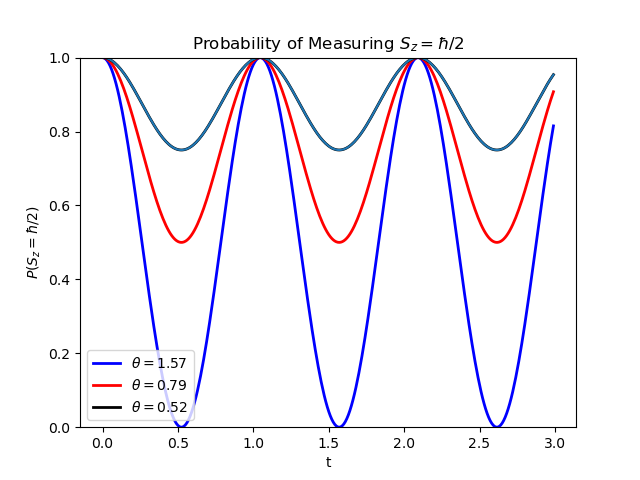

In [27]:
t = numpy.arange(0,3,0.01)
thetas = [numpy.pi/2, numpy.pi/4, numpy.pi/6]
colors = ['blue','red','black']

plt.figure()
for k in range(0, len(thetas)):
    theta = thetas[k]
    (energies, eigenstates) = numpy.linalg.eigh( Hamiltonian(theta, B) )
    prob_sz_up = numpy.zeros_like(t)
    psi_0_zbasis = numpy.matrix([[1],[0]])
    psi_0_Bbasis = numpy.dot( eigenstates.conj().T, psi_0_zbasis )
    for i in range(0, len(t)):
        psi_t_Bbasis = get_psi_t_Bbasis(energies, psi_0_Bbasis, t[i])
        overlap = numpy.dot(psi_0_Bbasis.conj().T, psi_t_Bbasis)[0,0]           # Συμπλη΄ρωστε τα κενά
        prob_sz_up[i] = (numpy.conjugate(overlap) * overlap).real # Συμπληρώστε τα κενά
    plt.plot(t, prob_sz_up, color=colors[k], lw=2, label=r'$\theta=$'+str("%.2f" %theta))
    

plt.plot(t, prob_sz_up)
plt.xlabel("t")
plt.ylabel(r"$P(S_z=\hbar/2)$")
plt.title(r"Probability of Measuring $S_z=\hbar/2$")
plt.legend()
plt.ylim([0,1])
plt.savefig("ProbSzUp_Solution.png")
plt.show()

COSMIC MUON STRIP CLUSTER SIMULATION
Strips in cluster: [210 211 212 213]
True hit position : 211.350
Gaussian sigma    : 0.85 strip units
Measured charges  : [ 54.6 169.3 141.   35. ]
Total charge      : 400.0
Reconstructed centroid : 211.3908
Centroid resolution    : 0.0408 strip units


FileNotFoundError: [Errno 2] No such file or directory: '/home/workdir/artifacts/gaussian_charge_cluster_strips_210-213.png'

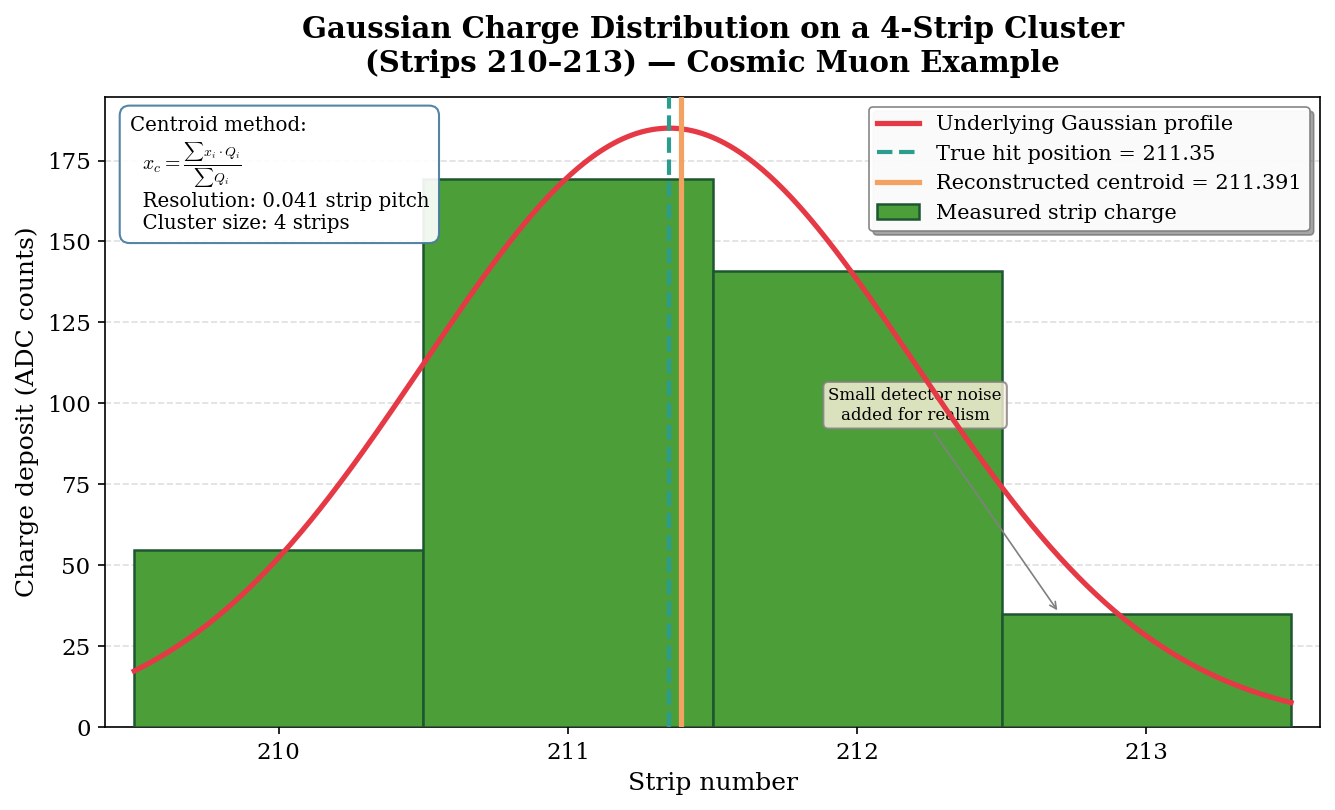

In [1]:
#!/usr/bin/env python3
"""
Generate a publication-quality figure for thesis:
Gaussian charge distribution across a 4-strip cluster (strips 210-213)
for cosmic muon track reconstruction using the centroid method.
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import matplotlib.patheffects as path_effects

# Set publication-quality style
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif', 'Times New Roman', 'serif'],
    'mathtext.fontset': 'cm',
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.grid': False,
    'axes.axisbelow': True,
})

# ====================== Simulation Parameters ======================
strip_ids = np.array([210, 211, 212, 213])
strip_positions = strip_ids.astype(float)  # Use strip number as position (arbitrary units)

true_hit_position = 211.35          # True crossing point (between strips 211 and 212)
sigma = 0.85                        # Gaussian sigma in strip units (narrow cluster)
amplitude = 185.0                   # Peak charge (ADC or arbitrary units)

# Small realistic noise (electronic + Poisson-like)
np.random.seed(42)
noise_level = 4.5

# Discrete charges sampled from Gaussian at strip centers + noise
true_gaussian = amplitude * np.exp( -(strip_positions - true_hit_position)**2 / (2 * sigma**2) )
charges = true_gaussian + np.random.normal(0, noise_level, len(strip_ids))
charges = np.clip(charges, 0, None)  # No negative charges

# ====================== Centroid Calculation ======================
total_charge = np.sum(charges)
centroid_position = np.sum(strip_positions * charges) / total_charge

print("=" * 60)
print("COSMIC MUON STRIP CLUSTER SIMULATION")
print("=" * 60)
print(f"Strips in cluster: {strip_ids}")
print(f"True hit position : {true_hit_position:.3f}")
print(f"Gaussian sigma    : {sigma:.2f} strip units")
print(f"Measured charges  : {np.round(charges, 1)}")
print(f"Total charge      : {total_charge:.1f}")
print(f"Reconstructed centroid : {centroid_position:.4f}")
print(f"Centroid resolution    : {abs(centroid_position - true_hit_position):.4f} strip units")
print("=" * 60)

# ====================== Plotting ======================
fig, ax = plt.subplots(figsize=(9, 5.5))

# Bar plot for discrete strip charges (no gaps)
bar_width = 1.0
bars = ax.bar(strip_positions, charges, width=bar_width, 
              color='#4C9F38', edgecolor='#1E5631', linewidth=1.2,
              align='center', zorder=3, label='Measured strip charge')

# Add subtle gradient or hatch for visual appeal (optional)
for bar in bars:
    bar.set_path_effects([path_effects.withStroke(linewidth=0.5, foreground='#1E5631')])

# Continuous Gaussian profile (smooth curve)
fine_x = np.linspace(strip_ids[0] - 0.5, strip_ids[-1] + 0.5, 500)
gaussian_curve = amplitude * np.exp( -(fine_x - true_hit_position)**2 / (2 * sigma**2) )
ax.plot(fine_x, gaussian_curve, color='#E63946', linewidth=2.5, 
        linestyle='-', zorder=4, label='Underlying Gaussian profile')

# True hit position (dashed green)
ax.axvline(true_hit_position, color='#2A9D8F', linestyle='--', linewidth=2.0,
           zorder=5, label=f'True hit position = {true_hit_position:.2f}')

# Reconstructed centroid (solid orange)
ax.axvline(centroid_position, color='#F4A261', linestyle='-', linewidth=2.5,
           zorder=6, label=f'Reconstructed centroid = {centroid_position:.3f}')

# Styling
ax.set_xlabel('Strip number', fontweight='medium')
ax.set_ylabel('Charge deposit (ADC counts)', fontweight='medium')
ax.set_title('Gaussian Charge Distribution on a 4-Strip Cluster\n(Strips 210–213) — Cosmic Muon Example', 
             pad=12, fontweight='bold')

# X-axis ticks exactly at strip centers
ax.set_xticks(strip_ids)
ax.set_xlim(strip_ids[0] - 0.6, strip_ids[-1] + 0.6)
ax.set_ylim(0, max(charges) * 1.15)

# Grid for readability (light)
ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_axisbelow(True)

# Legend
legend = ax.legend(loc='upper right', framealpha=0.95, fancybox=True, 
                   edgecolor='gray', shadow=True)
legend.get_frame().set_linewidth(0.8)

# Add informative text box (thesis-style)
textstr = (f'Centroid method:\n'
           f'  $x_c = \\frac{{\\sum x_i \\cdot Q_i}}{{\\sum Q_i}}$\n'
           f'  Resolution: {abs(centroid_position - true_hit_position):.3f} strip pitch\n'
           f'  Cluster size: 4 strips')
props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#457B9D', alpha=0.92)
ax.text(0.02, 0.97, textstr, transform=ax.transAxes, fontsize=9.5,
        verticalalignment='top', bbox=props, zorder=7,
        family='serif')

# Add small annotation for noise
ax.annotate('Small detector noise\nadded for realism', xy=(212.7, 35), xytext=(212.2, 95),
            fontsize=8, ha='center',
            arrowprops=dict(arrowstyle='->', color='gray', lw=0.8),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF3E0', edgecolor='gray', alpha=0.8))

# Tight layout
plt.tight_layout()

# Save high-resolution figure for thesis
output_path = '/home/workdir/artifacts/gaussian_charge_cluster_strips_210-213.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
print(f"\nFigure saved to: {output_path}")
print("Ready for thesis inclusion (300 dpi).")

# Optional: also save as PDF for vector graphics
pdf_path = '/home/workdir/artifacts/gaussian_charge_cluster_strips_210-213.pdf'
plt.savefig(pdf_path, format='pdf', bbox_inches='tight', facecolor='white')
print(f"Vector PDF also saved to: {pdf_path}")

plt.close()
print("\nDone! You can now insert the PNG or PDF into your thesis.")